# FraudGuard — 03: Baseline Model (Logistic Regression)

Sınıf dengesizliğine müdahale edilmeden eğitilen referans model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yaml
import json
import joblib
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)

np.random.seed(42)

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
METRICS_DIR   = Path('../results/metrics')
FIGURES_DIR   = Path('../results/figures')

In [2]:
with open('../config/model_params.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

LR_CFG = cfg['logistic_regression']
print('Logistic Regression config:', LR_CFG)

Logistic Regression config: {'random_state': 42, 'max_iter': 1000, 'C': 1.0, 'solver': 'lbfgs'}


## 1. Veriyi Yükle

In [3]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train_scaled.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test_scaled.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Train fraud: {y_train.sum()} ({y_train.mean():.4%})')
print(f'Test  fraud: {y_test.sum()}  ({y_test.mean():.4%})')

X_train: (227845, 30)  |  X_test: (56962, 30)
Train fraud: 394 (0.1729%)
Test  fraud: 98  (0.1720%)


## 2. Model Eğitimi

In [4]:
model = LogisticRegression(
    C=LR_CFG['C'],
    max_iter=LR_CFG['max_iter'],
    solver=LR_CFG['solver'],
    random_state=LR_CFG['random_state']
)

model.fit(X_train, y_train)
print('Model eğitildi.')
print(f'Iterasyon sayısı: {model.n_iter_[0]}')

Model eğitildi.
Iterasyon sayısı: 23


## 3. Tahmin

In [5]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print('Tahmin tamamlandı.')
print(f'Tahmin edilen fraud sayısı: {y_pred.sum()}')
print(f'Gerçek fraud sayısı:        {y_test.sum()}')

Tahmin tamamlandı.
Tahmin edilen fraud sayısı: 75
Gerçek fraud sayısı:        98


## 4. Metrikler

In [6]:
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)
pr_auc    = average_precision_score(y_test, y_pred_proba)

print('=== Baseline Logistic Regression — Test Seti Metrikleri ===')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1        : {f1:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')
print(f'PR-AUC    : {pr_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

=== Baseline Logistic Regression — Test Seti Metrikleri ===
Precision : 0.8267
Recall    : 0.6327
F1        : 0.7168
ROC-AUC   : 0.9605
PR-AUC    : 0.7414

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## 5. Confusion Matrix

TN=56,851  FP=13  FN=36  TP=62

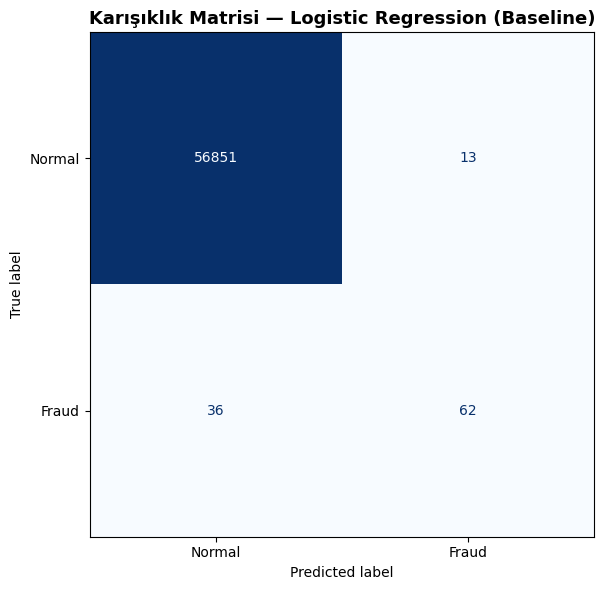

Saved: 07_lr_confusion_matrix.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Karışıklık Matrisi — Logistic Regression (Baseline)', fontsize=13, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_lr_confusion_matrix.png')

## 6. ROC ve PR Eğrileri

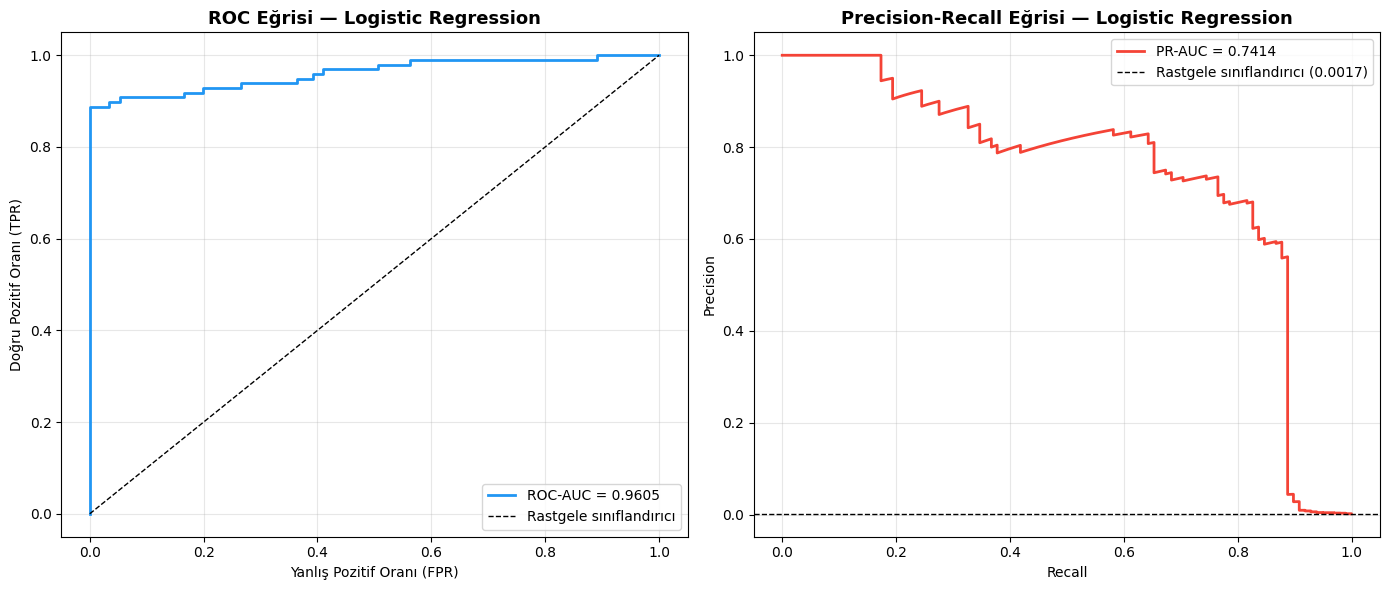

Saved: 08_lr_roc_pr_curves.png


In [8]:
fpr, tpr, _     = roc_curve(y_test, y_pred_proba)
prec, rec, _    = precision_recall_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
axes[0].plot(fpr, tpr, color='#2196F3', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele sınıflandırıcı')
axes[0].set_xlabel('Yanlış Pozitif Oranı (FPR)')
axes[0].set_ylabel('Doğru Pozitif Oranı (TPR)')
axes[0].set_title('ROC Eğrisi — Logistic Regression', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# PR
baseline_rate = y_test.mean()
axes[1].plot(rec, prec, color='#F44336', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[1].axhline(y=baseline_rate, color='k', linestyle='--', lw=1,
                label=f'Rastgele sınıflandırıcı ({baseline_rate:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Eğrisi — Logistic Regression', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_lr_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_lr_roc_pr_curves.png')

## 7. Model ve Metrik Kaydet

In [9]:
joblib.dump(model, MODELS_DIR / 'logistic_regression.pkl')
print('Model kaydedildi: models/logistic_regression.pkl')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

metrics = {
    'model': 'LogisticRegression',
    'step': '05_baseline',
    'class_weight': None,
    'smote': False,
    'precision': round(float(precision), 4),
    'recall':    round(float(recall),    4),
    'f1':        round(float(f1),        4),
    'roc_auc':   round(float(roc_auc),   4),
    'pr_auc':    round(float(pr_auc),    4),
    'confusion_matrix': {
        'TN': int(tn), 'FP': int(fp),
        'FN': int(fn), 'TP': int(tp)
    }
}

with open(METRICS_DIR / '05_baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))
print('\nSaved: 05_baseline_metrics.json')

Model kaydedildi: models/logistic_regression.pkl
{
  "model": "LogisticRegression",
  "step": "05_baseline",
  "class_weight": null,
  "smote": false,
  "precision": 0.8267,
  "recall": 0.6327,
  "f1": 0.7168,
  "roc_auc": 0.9605,
  "pr_auc": 0.7414,
  "confusion_matrix": {
    "TN": 56851,
    "FP": 13,
    "FN": 36,
    "TP": 62
  }
}

Saved: 05_baseline_metrics.json
